In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import datasets as hf_datasets
from datasets import load_dataset

import numpy as np
import healpy as hp
import pandas as pd
import matplotlib.pyplot as plt
import pymaster as nmt
from astropy.io import fits
from tqdm import tqdm
import camb
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar

import glass.shells
import glass.lensing

### Load the dataset

In [3]:
path_dataset = "/lustre/fswork/projects/rech/prk/commun/GowerStreetSims/UNIONS_sims_pseudo_cell.parquet"

dataset = load_dataset("parquet", data_files=path_dataset)

Generating train split: 0 examples [00:00, ? examples/s]

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'h', 'Omega_m', 'Omega_b', 'sigma_8', 'n_s', 'w', 'm_nu', 'A_s', 'ell_eff', 'pseudo_cell', 'pseudo_cell_sys'],
        num_rows: 39500
    })
})

In [19]:
str(dataset['train'][2]['id'])

'310512000'

In [42]:
def get_theory_cell(row):
    nside = 512
    lmax = 2*nside
    pw = hp.pixwin(nside, lmax=lmax)

    h = row['h']
    Om = row['Omega_m']
    Ob = row['Omega_b']
    Oc = Om - Ob
    ns = row['n_s']
    m_nu = row['m_nu']
    w = row['w']
    As = row['A_s']

    pars = camb.set_params(H0=100*h, omch2=Oc*h**2, ombh2=Ob*h**2, ns=ns, mnu=m_nu, w=w, As=As, WantTransfer=True, NonLinear=camb.model.NonLinear_both)
    Onu = pars.omeganu
    Oc = Om - Ob - Onu
    pars = camb.set_params(H0=100*h, omch2=Oc*h**2, ombh2=Ob*h**2, ns=ns, mnu=m_nu, w=w, As=As, WantTransfer=True, NonLinear=camb.model.NonLinear_both)

    sim_id = row['id']
    sim_number = int(str(sim_id)[:-7])
    rot_ra = int(str(sim_id)[-3])
    rot_dec = int(str(sim_id)[-2])
    noise_real = int(str(sim_id)[-1])

    path_output = f"/lustre/fswork/projects/rech/prk/commun/GowerStreetSims/UNIONS_processing/forward_model_sim{sim_number:05d}_nside0512_rot{rot_ra}{rot_dec}_noisereal{noise_real}.npy"
    output = np.load(path_output, allow_pickle=True).item()

    redshift_distr = np.loadtxt(output['config']['redshift_distribution']['path_dndz'])
    z, dndz = redshift_distr[:, 0], redshift_distr[:, 1]

    try:
        z_shift = z + output['nuisance_parameters']['bin_1']['delta_z']
        f = interp1d(z, dndz, kind='cubic', fill_value=0.0, bounds_error=False)
        dndz = f(z_shift)
        dndz /= np.trapz(dndz, z)
    except KeyError:
        pass

    pars.min_l = 1
    pars.set_for_lmax(lmax)
    pars.SourceWindows = [
        camb.sources.SplinedSourceWindow(z=z, W=dndz, source_type='lensing')
    ]
    theory_cls = camb.get_results(pars).get_source_cls_dict(lmax=lmax, raw_cl=True)
    m_bias = output['nuisance_parameters']['bin_1']['m_bias']
    print(m_bias)
    return theory_cls['W1xW1']*pw**2*(1+m_bias**2)

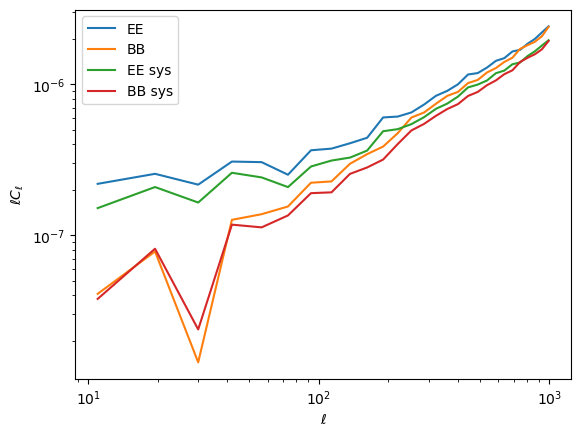

In [45]:
index = 2

nside=512
lmax = 2*nside

plt.figure()

l = np.arange(lmax+1)

row = dataset["train"][index]

ell_eff = row["ell_eff"]
cl_all = np.array(row["pseudo_cell"]).reshape((4, -1))
cl_all_sys = np.array(row["pseudo_cell_sys"]).reshape((4, -1))

plt.plot(ell_eff, ell_eff*cl_all[0], label="EE")
plt.plot(ell_eff, ell_eff*cl_all[3], label="BB")
plt.plot(ell_eff, ell_eff*cl_all_sys[0], label="EE sys")
plt.plot(ell_eff, ell_eff*cl_all_sys[3], label="BB sys")

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell C_\ell$')

plt.legend()

plt.xscale('log')
plt.yscale('log')

plt.show()


7.036436732810701e-05


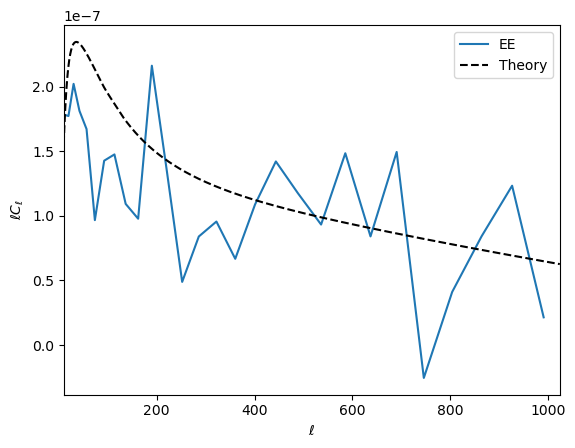

In [48]:
index = 2

nside=512
lmax = 2*nside

plt.figure()

l = np.arange(lmax+1)

row = dataset["train"][index]

ell_eff = row["ell_eff"]
cl_all = np.array(row["pseudo_cell"]).reshape((4, -1))
cl_all_sys = np.array(row["pseudo_cell_sys"]).reshape((4, -1))

cl_theory = get_theory_cell(row)

plt.plot(ell_eff, ell_eff*(cl_all[0]-cl_all[3]), label="EE")
plt.plot(l, l*cl_theory, label="Theory", linestyle='--', c='k')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell C_\ell$')

plt.legend()

#plt.xscale('log')
#plt.yscale('log')

plt.xlim(10, 1024)

plt.show()